In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

# Load the cleaned dataset
df = pd.read_csv('Dataset_cleaned.csv')

# Display the dataset
df.head()

,restaurant_id,restaurant_name,country_code,city,address,locality,locality_verbose,longitude,latitude,cuisines,average_cost_for_two,currency,has_table_booking,has_online_delivery,is_delivering_now,switch_to_order_menu,price_range,aggregate_rating,rating_color,rating_text,votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenue, Poblacion, Makati City","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Makati City",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Makati City",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Mandaluyong City",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandaluyong City",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandaluyong City",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Task 1: Restaurant Reviews

**1. Analyze the text reviews to identify the most common positive and negative keywords.**

In [2]:
# Count restaurants by rating category
rating_counts = df['rating_text'].value_counts()

print(rating_counts)

rating_text
Average      3737
Not rated    2148
Good         2100
Very Good    1079
Excellent     301
Poor          186
Name: count, dtype: int64


In [3]:
# Define rating categories
positive_ratings = ['Good', 'Very Good', 'Excellent']
neutral_ratings = ['Average']
negative_ratings = ['Poor']
unrated = ['Not rated']


# Count ratings in each category
positive_counts = df[df['rating_text'].isin(positive_ratings)]['rating_text'].value_counts()

neutral_counts = df[df['rating_text'].isin(neutral_ratings)]['rating_text'].value_counts()

negative_counts = df[df['rating_text'].isin(negative_ratings)]['rating_text'].value_counts()

unrated_counts = df[df['rating_text'].isin(unrated)]['rating_text'].value_counts()


# Display results
print("Positive Ratings:")
print(positive_counts)

print("\nNeutral Ratings:")
print(neutral_counts)

print("\nNegative Ratings:")
print(negative_counts)

print("\nUnrated:")
print(unrated_counts)

Positive Ratings:
rating_text
Good         2100
Very Good    1079
Excellent     301
Name: count, dtype: int64

Neutral Ratings:
rating_text
Average    3737
Name: count, dtype: int64

Negative Ratings:
rating_text
Poor    186
Name: count, dtype: int64

Unrated:
rating_text
Not rated    2148
Name: count, dtype: int64


> **Conclusion:** Among the rating categories, **Good** is the most common positive rating with **2,100 restaurants**, while **Poor** is the most common negative rating with **186 restaurants**. `Average` and `Not rated` are treated separately.

**2. Calculate the average length of reviews and explore if there is a relationship between review length and rating.**

In [4]:
# Calculate the number of characters in each Rating Text
df['rating_text_char_length'] = df['rating_text'].str.len()

# Calculate the number of words in each Rating Text
df['rating_text_word_length'] = df['rating_text'].str.split().str.len()

# Display Rating Text with its character and word length
df[['rating_text', 'rating_text_char_length', 
   'rating_text_word_length']].head()

,rating_text,rating_text_char_length,rating_text_word_length
0,Excellent,9,1
1,Excellent,9,1
2,Very Good,9,2
3,Excellent,9,1
4,Excellent,9,1


In [5]:
# Average character length
average_char_length = df['rating_text_char_length'].mean()

# Average word length
average_word_length = df['rating_text_word_length'].mean()

print("Average Rating Text Character Length:", round(average_char_length, 2))
print("Average Rating Text Word Length:", round(average_word_length, 2))

Average Rating Text Character Length: 7.02
Average Rating Text Word Length: 1.34


In [6]:
rating_analysis = df.groupby('rating_text').agg(
    average_rating=('aggregate_rating', 'mean'),
    average_char_length=('rating_text_char_length', 'mean'),
    average_word_length=('rating_text_word_length', 'mean'),
    restaurant_count=('restaurant_id', 'count')
).sort_values('average_rating', ascending=False)

rating_analysis

,average_rating,average_char_length,average_word_length,restaurant_count
rating_text,,,,
Excellent,4.659801,9.0,1.0,301
Very Good,4.168119,9.0,2.0,1079
Good,3.683429,4.0,1.0,2100
Average,3.051619,7.0,1.0,3737
Poor,2.297849,4.0,1.0,186
Not rated,0.000000,9.0,2.0,2148


In [7]:
# Calculate correlation between rating text length and aggregate rating
correlation = df['rating_text_char_length'].corr(
    df['aggregate_rating']
)

# Display the correlation value
print(
    "Correlation between Rating Text Length and Aggregate Rating:",
    round(correlation, 3)
)

Correlation between Rating Text Length and Aggregate Rating: -0.479


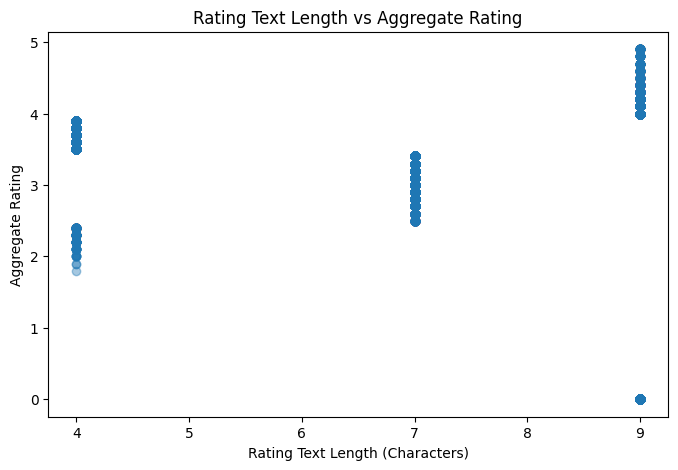

In [8]:
# Create scatter plot to visualize the relationship
plt.figure(figsize=(8, 5))

plt.scatter(
    df['rating_text_char_length'],
    df['aggregate_rating'],
    alpha=0.4
)

# Add labels and title
plt.xlabel("Rating Text Length (Characters)")
plt.ylabel("Aggregate Rating")
plt.title("Rating Text Length vs Aggregate Rating")

# Display the plot
plt.show()

In [9]:
print("Conclusion:")
print("Raw review text was not available in the dataset.")
print("Therefore, Rating Text was used as a proxy for review length.")
print("The analysis compares the length of rating labels with aggregate ratings.")
print("This is a proxy analysis and should not be considered actual review-length analysis.")

Conclusion:
Raw review text was not available in the dataset.
Therefore, Rating Text was used as a proxy for review length.
The analysis compares the length of rating labels with aggregate ratings.
This is a proxy analysis and should not be considered actual review-length analysis.


## Task 2: Votes Analysis

**1. Identify the restaurants with the highest and lowest number of votes.**

In [10]:
# Identify restaurants with the highest and lowest votes
highest_votes = df.loc[df['votes'].idxmax(), ['restaurant_name', 'votes']]
lowest_votes = df.loc[df['votes'].idxmin(), ['restaurant_name', 'votes']]

print("Restaurant with highest votes:")
print(highest_votes)

print("\nRestaurant with lowest votes:")
print(lowest_votes)

Restaurant with highest votes:
restaurant_name     Toit
votes              10934
Name: 728, dtype: object

Restaurant with lowest votes:
restaurant_name    Cantinho da Gula
votes                             0
Name: 69, dtype: object


> **Conclusion:** Toit has the highest number of votes with **10,934**, while **Cantinho da Gula** has the lowest with **0 votes**.

**2. Analyze if there is a correlation between the number of votes and the rating of a restaurant.**

In [11]:
# Calculate correlation between votes and rating
correlation = df[['votes', 'aggregate_rating']].corr().iloc[0, 1]

print("Correlation between votes and rating:", round(correlation, 2))

Correlation between votes and rating: 0.31


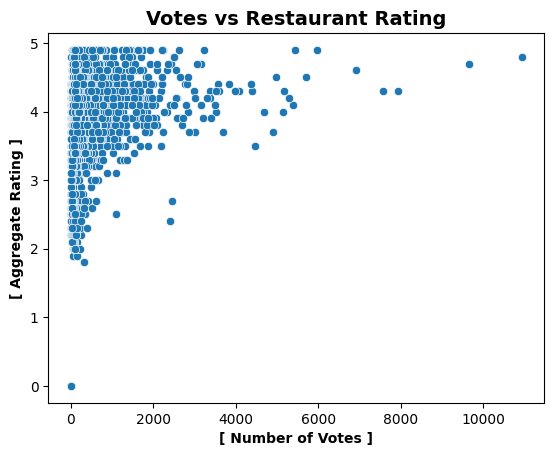

In [12]:
# Visualize the relationship between votes and rating
sns.scatterplot(data=df, x='votes', y='aggregate_rating')

plt.title('Votes vs Restaurant Rating', fontsize = 14, fontweight = 'bold')
plt.xlabel('[ Number of Votes ]', fontsize = 10, fontweight = 'bold')
plt.ylabel('[ Aggregate Rating ]', fontsize = 10, fontweight = 'bold')
plt.show()

> **Conclusion:** There is a **weak positive correlation (0.31)** between the number of votes and restaurant ratings, indicating that restaurants with more votes tend to have slightly higher ratings, but the relationship is not very strong.


## Task 3: Price Range vs. Online Delivery and Table Booking

**1. Analyze if there is a relationship between the price range and the availability of online delivery and table booking.**
**2. Determine if higher-priced restaurants are more likely to offer these services.**

In [13]:
# Compare online delivery and table booking by price range
price_services = df.groupby('price_range').agg(
    online_delivery=('has_online_delivery', lambda x: (x == 'Yes').mean() * 100),
    table_booking=('has_table_booking', lambda x: (x == 'Yes').mean() * 100)
).round(2)

price_services

,online_delivery,table_booking
price_range,,
1,15.77,0.02
2,41.31,7.68
3,29.19,45.74
4,9.04,46.76


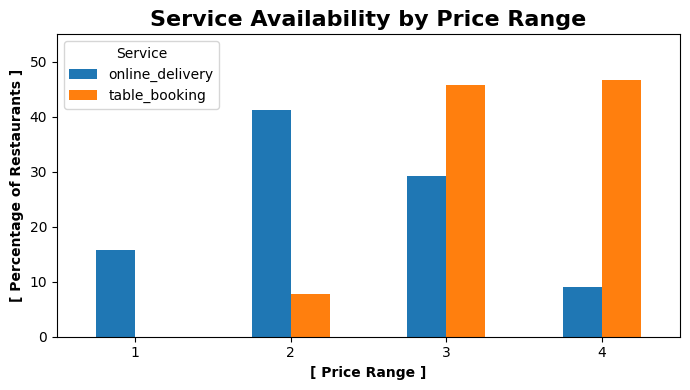

In [14]:
# Plot service availability across different price ranges
price_services.plot(kind='bar', figsize=(7, 4))

# Add chart title and axis labels
plt.title('Service Availability by Price Range', fontsize=16, fontweight='bold')
plt.xlabel('[ Price Range ]', fontweight='bold')
plt.ylabel('[ Percentage of Restaurants ]', fontweight='bold')

# Format x-axis and legend
plt.xticks(rotation=0)
plt.legend(title='Service')

# Set y-axis limit
plt.ylim(0, 55)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

> **Conclusion:** Price range shows a clear relationship with service availability. **Table booking is much more common among higher-priced restaurants**, increasing from **0.02%** in Price Range 1 to **46.76%** in Price Range 4. Online delivery is highest in Price Range 2 (**41.31%**) but decreases to **9.04%** in Price Range 4. Therefore, **higher-priced restaurants are more likely to offer table booking, but not online delivery**.